In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from collections import defaultdict
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Assuming you have your data in a DataFrame `df` and the target variable in `target`
df = pd.read_csv('/kaggle/input/combo2/COMBO2.csv')
target = df["is_stroke_face"]
features = df.drop(['Filename', "is_stroke_face"], axis=1)
# Split the data


hyperparameters_RFC = {'n_estimators': 300, 'max_depth': 90, 'min_samples_split': 6, 'min_samples_leaf': 3,
                       'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'entropy'}

hyperparameters_XGB = {'max_depth': 9,
                       'min_child_weight': 1,
                       'learning_rate': 0.2,
                       'subsample': 0.8,
                       'colsample_bytree': 1.0,
                       'gamma': 0,
                       'n_estimators': 600,
                       'use_label_encoder': False,
                       'eval_metric': 'rmse',
                       'objective': 'binary:logistic'}

hyperparameters_CB = {'bagging_temperature': 0.8607305832563434, 'bootstrap_type': 'MVS',
                      'colsample_bylevel': 0.917411003148779,
                      'depth': 8, 'grow_policy': 'SymmetricTree', 'iterations': 918, 'l2_leaf_reg': 8,
                      'learning_rate': 0.29287291117375575, 'max_bin': 231, 'min_data_in_leaf': 9, 'od_type': 'Iter',
                      'od_wait': 21, 'one_hot_max_size': 7, 'random_strength': 0.6963042728397884,
                      'scale_pos_weight': 1.924541179848884, 'subsample': 0.6480869299533999}
FACE_INDEXES = {
    "lipsUpperOuter": [61, 185, 40, 39, 37, 0, 267, 269, 270, 409, 291],
    "lipsLowerOuter": [146, 91, 181, 84, 17, 314, 405, 321, 375, 291],
    "lipsUpperInner": [78, 191, 80, 81, 82, 13, 312, 311, 310, 415, 308],
    "lipsLowerInner": [78, 95, 88, 178, 87, 14, 317, 402, 318, 324, 308],
    "rightEyeUpper0": [246, 161, 160, 159, 158, 157, 173],
    "rightEyeLower0": [33, 7, 163, 144, 145, 153, 154, 155, 133],
    "rightEyeUpper1": [247, 30, 29, 27, 28, 56, 190],
    "rightEyeLower1": [130, 25, 110, 24, 23, 22, 26, 112, 243],
    "rightEyeUpper2": [113, 225, 224, 223, 222, 221, 189],
    "rightEyeLower2": [226, 31, 228, 229, 230, 231, 232, 233, 244],
    "rightEyeLower3": [143, 111, 117, 118, 119, 120, 121, 128, 245],
    "rightEyebrowUpper": [156, 70, 63, 105, 66, 107, 55, 193],
    "rightEyebrowLower": [35, 124, 46, 53, 52, 65],
    "leftEyeUpper0": [466, 388, 387, 386, 385, 384, 398],
    "leftEyeLower0": [263, 249, 390, 373, 374, 380, 381, 382, 362],
    "leftEyeUpper1": [467, 260, 259, 257, 258, 286, 414],
    "leftEyeLower1": [359, 255, 339, 254, 253, 252, 256, 341, 463],
    "leftEyeUpper2": [342, 445, 444, 443, 442, 441, 413],
    "leftEyeLower2": [446, 261, 448, 449, 450, 451, 452, 453, 464],
    "leftEyeLower3": [372, 340, 346, 347, 348, 349, 350, 357, 465],
    "leftEyebrowUpper": [383, 300, 293, 334, 296, 336, 285, 417],
    "leftEyebrowLower": [265, 353, 276, 283, 282, 295],
    "midwayBetweenEyes": [168],
    # "noseTip": [1],
    "noseBottom": [2],
    "noseRightCorner": [98],
    "noseLeftCorner": [327],
    "rightCheek": [205, 137, 123, 50, 203, 177, 147, 187, 207, 216, 215, 213, 192, 214, 212, 138, 135, 210, 169],
    "leftCheek": [425, 352, 280, 330, 266, 423, 426, 427, 411, 376, 436, 416, 432, 434, 422, 430, 364, 394, 371]
}

models = {
    "RandomForest": RandomForestClassifier(**hyperparameters_RFC, random_state=150),
    "CatBoost": CatBoostClassifier(**hyperparameters_CB),
    "XGBoost": XGBClassifier(**hyperparameters_XGB)
}

all_importances = {model: {region: 0 for region in FACE_INDEXES} for model in models}

for name, model in models.items():
    for i in range(5):
        X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=50 * i)
        model.fit(X_train, y_train)
        importances = pd.Series(model.feature_importances_, index=features.columns)
        importances_by_index = importances.to_dict()
        for region, indexs in FACE_INDEXES.items():
            for index in indexs:
                if name == "CatBoost":
                    importances_by_index[f"{region}_{index}"] /= 100
                all_importances[name][region] += importances_by_index[f"{region}_{index}"]

# Convert all_importances to DataFrame
importances_df = pd.DataFrame(all_importances)

# Transpose the DataFrame to get models as columns and regions as rows
importances_df = importances_df.transpose()

# Save the DataFrame to CSV
importances_df.to_csv('model_importances.csv')

0:	learn: 0.5681236	total: 167ms	remaining: 2m 33s
1:	learn: 0.4937897	total: 267ms	remaining: 2m 2s
2:	learn: 0.4512025	total: 359ms	remaining: 1m 49s
3:	learn: 0.4121395	total: 508ms	remaining: 1m 56s
4:	learn: 0.3844898	total: 605ms	remaining: 1m 50s
5:	learn: 0.3671607	total: 701ms	remaining: 1m 46s
6:	learn: 0.3522586	total: 849ms	remaining: 1m 50s
7:	learn: 0.3337790	total: 951ms	remaining: 1m 48s
8:	learn: 0.3127500	total: 1.04s	remaining: 1m 45s
9:	learn: 0.2988677	total: 1.19s	remaining: 1m 48s
10:	learn: 0.2888633	total: 1.29s	remaining: 1m 46s
11:	learn: 0.2762320	total: 1.38s	remaining: 1m 44s
12:	learn: 0.2707546	total: 1.53s	remaining: 1m 46s
13:	learn: 0.2641987	total: 1.63s	remaining: 1m 45s
14:	learn: 0.2576931	total: 1.72s	remaining: 1m 43s
15:	learn: 0.2492887	total: 1.87s	remaining: 1m 45s
16:	learn: 0.2423029	total: 1.97s	remaining: 1m 44s
17:	learn: 0.2391026	total: 2.07s	remaining: 1m 43s
18:	learn: 0.2313077	total: 2.21s	remaining: 1m 44s
19:	learn: 0.2227294	to

<Figure size 1200x700 with 0 Axes>

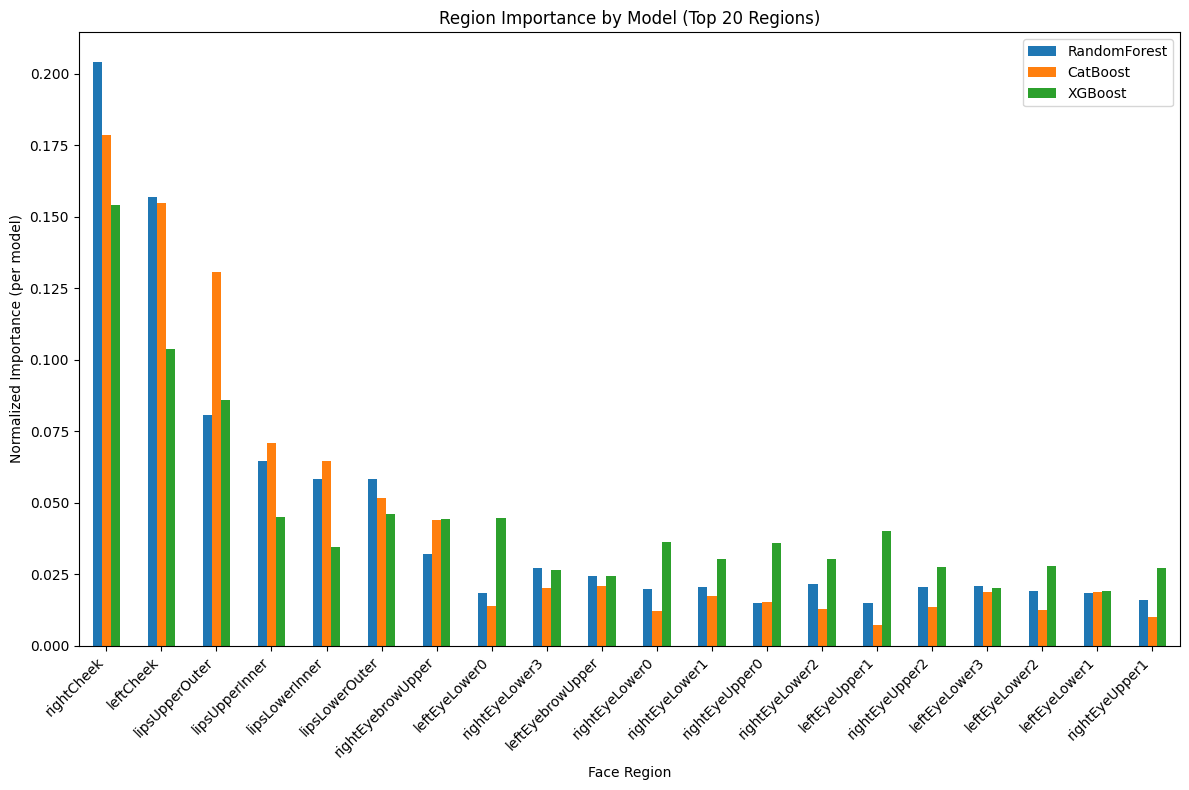

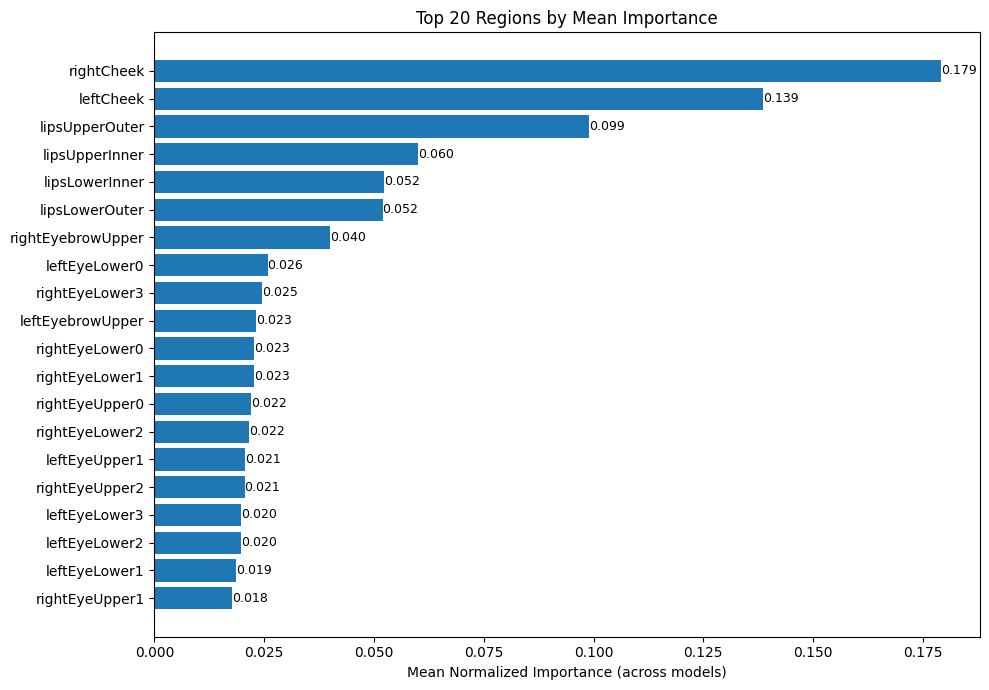

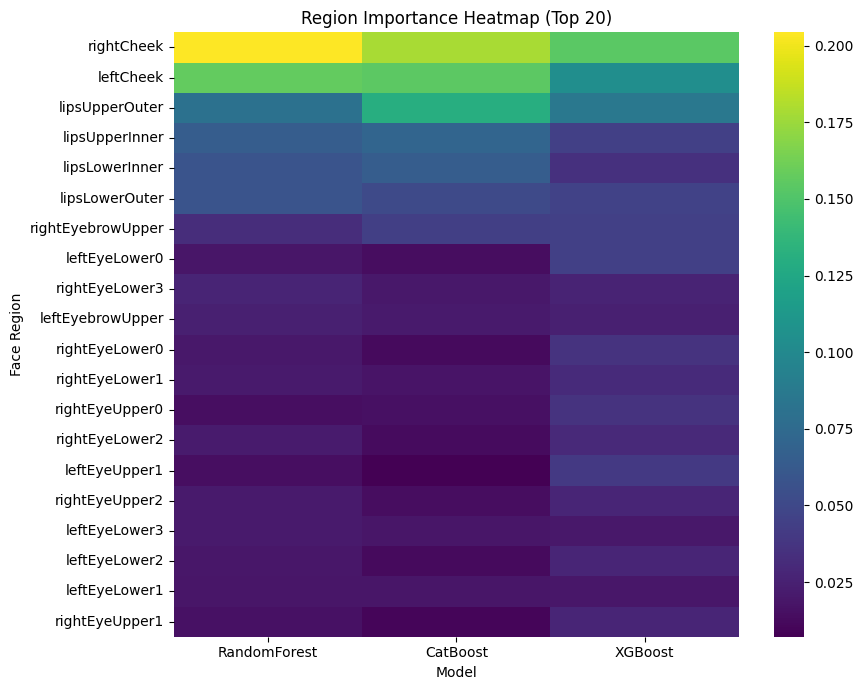

In [2]:
# === Region-level Importance Visualizations ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your region-aggregated importances
imp_df = pd.read_csv("model_importances.csv", index_col=0)  # rows=models, cols=regions (sums across 5 splits)

# 1) Average across the 5 runs (you summed; divide by 5 to average)
imp_avg = imp_df / 5.0

# 2) Normalize per model so each row sums to 1 (comparability across models)
imp_norm = imp_avg.div(imp_avg.sum(axis=1), axis=0)

# 3) Top-N regions by mean across models (optional focusing)
top_n = 20
region_means = imp_norm.mean(axis=0).sort_values(ascending=False)
top_regions = region_means.head(top_n).index
imp_top = imp_norm[top_regions]  # models x regions (subset)

# --- Clustered bar: each model vs region (top-N regions) ---
plt.figure(figsize=(12, max(5, 0.35*len(top_regions))))
imp_top.T.plot(kind="bar", figsize=(12, max(5, 0.4*len(top_regions))))
plt.ylabel("Normalized Importance (per model)")
plt.xlabel("Face Region")
plt.title(f"Region Importance by Model (Top {top_n} Regions)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Horizontal bar: overall (mean across models) ---
plt.figure(figsize=(10, max(5, 0.35*len(top_regions))))
plt.barh(region_means.head(top_n).index, region_means.head(top_n).values)
plt.gca().invert_yaxis()
plt.xlabel("Mean Normalized Importance (across models)")
plt.title(f"Top {top_n} Regions by Mean Importance")
for i, v in enumerate(region_means.head(top_n).values):
    plt.text(v, i, f"{v:.3f}", va="center", ha="left", fontsize=9)
plt.tight_layout()
plt.show()

# --- Heatmap: regions (rows) x models (cols) for top-N regions ---
plt.figure(figsize=(9, max(6, 0.35*len(top_regions))))
sns.heatmap(imp_top.T, cmap="viridis")
plt.title(f"Region Importance Heatmap (Top {top_n})")
plt.xlabel("Model")
plt.ylabel("Face Region")
plt.tight_layout()
plt.show()


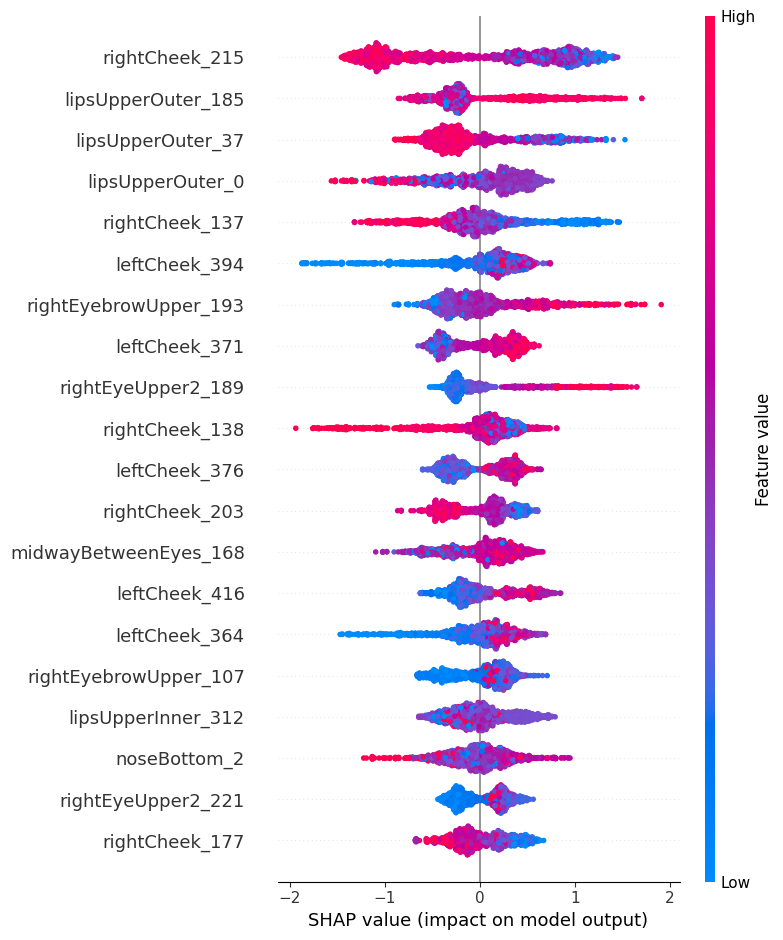

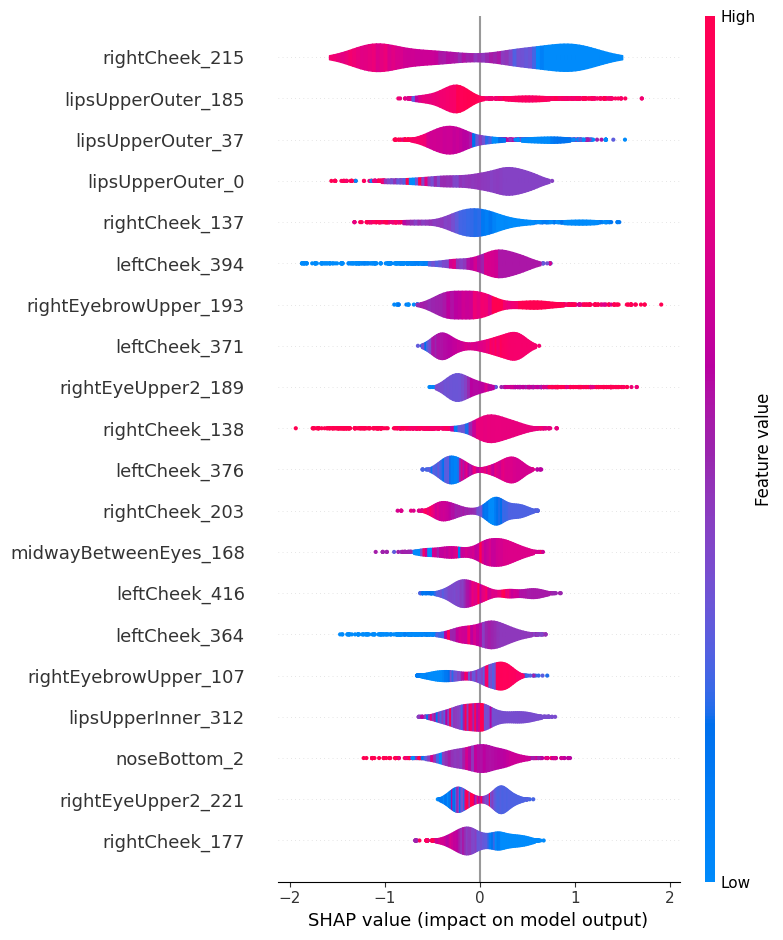

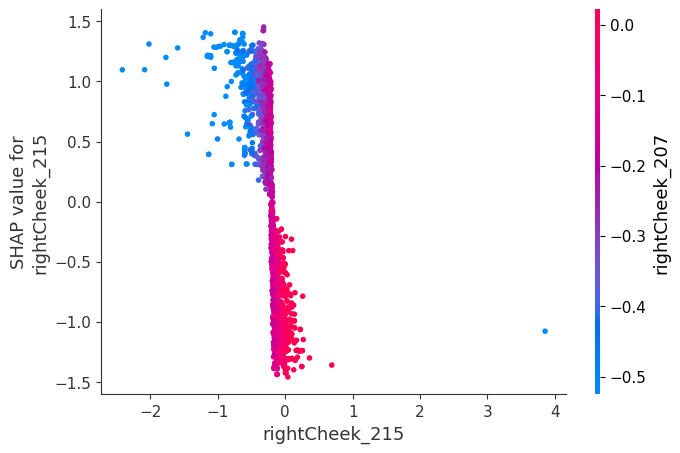

In [3]:
# === SHAP Summary / Beeswarm & Dependence Plots (XGBoost) ===
import pandas as pd
import numpy as np

# Ensure shap is available
try:
    import shap
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

# Refit a clean model on full data (or use train set) for explanation
xgb_for_shap = XGBClassifier(**hyperparameters_XGB)
xgb_for_shap.fit(features, target)

# Build a manageable sample for speed (optional but recommended)
X_full = features.copy()
sample_n = min(2500, len(X_full))
X_sample = X_full.sample(sample_n, random_state=42) if len(X_full) > sample_n else X_full

# Compute SHAP values (TreeExplainer works well for XGBoost)
explainer = shap.TreeExplainer(xgb_for_shap)
shap_values = explainer.shap_values(X_sample)

# For binary classification, xgboost returns a (n_samples, n_features) array
# (if it returns a list, take shap_values[1] for the positive class)
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]
else:
    shap_vals_to_plot = shap_values

# ---- SHAP Summary / Beeswarm ----
shap.summary_plot(shap_vals_to_plot, X_sample, show=True)  # dot/beeswarm
# Alternative violin:
shap.summary_plot(shap_vals_to_plot, X_sample, plot_type="violin", show=True)

# ---- SHAP Dependence Plot ----
# Choose top feature by mean |SHAP|
mean_abs = np.abs(shap_vals_to_plot).mean(axis=0)
top_feat_name = X_sample.columns[np.argmax(mean_abs)]

shap.dependence_plot(top_feat_name, shap_vals_to_plot, X_sample, show=True)


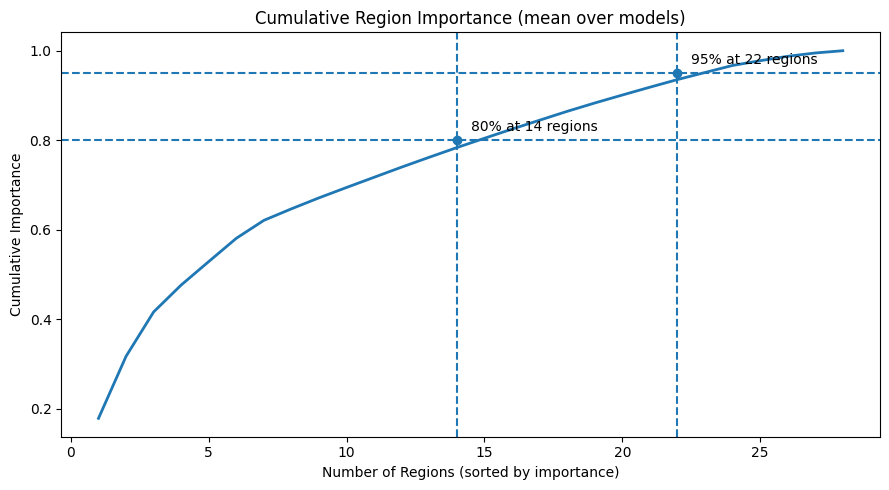

In [4]:
# === Region-level Cumulative Importance (across models) ===
region_mean = imp_norm.mean(axis=0).sort_values(ascending=False)  # mean over models, sums to 1 across all regions
cum = region_mean.cumsum()
k80 = int((cum <= 0.80).sum())
k95 = int((cum <= 0.95).sum())

plt.figure(figsize=(9,5))
plt.plot(range(1, len(region_mean)+1), cum.values, linewidth=2)
plt.axhline(0.80, linestyle='--')
plt.axhline(0.95, linestyle='--')
plt.axvline(k80, linestyle='--')
plt.axvline(k95, linestyle='--')
plt.scatter([k80, k95], [0.80, 0.95])

plt.title("Cumulative Region Importance (mean over models)")
plt.xlabel("Number of Regions (sorted by importance)")
plt.ylabel("Cumulative Importance")
plt.text(k80+0.5, 0.80+0.02, f"80% at {k80} regions", fontsize=10)
plt.text(k95+0.5, 0.95+0.02, f"95% at {k95} regions", fontsize=10)
plt.tight_layout()
plt.show()


<Figure size 1200x735 with 0 Axes>

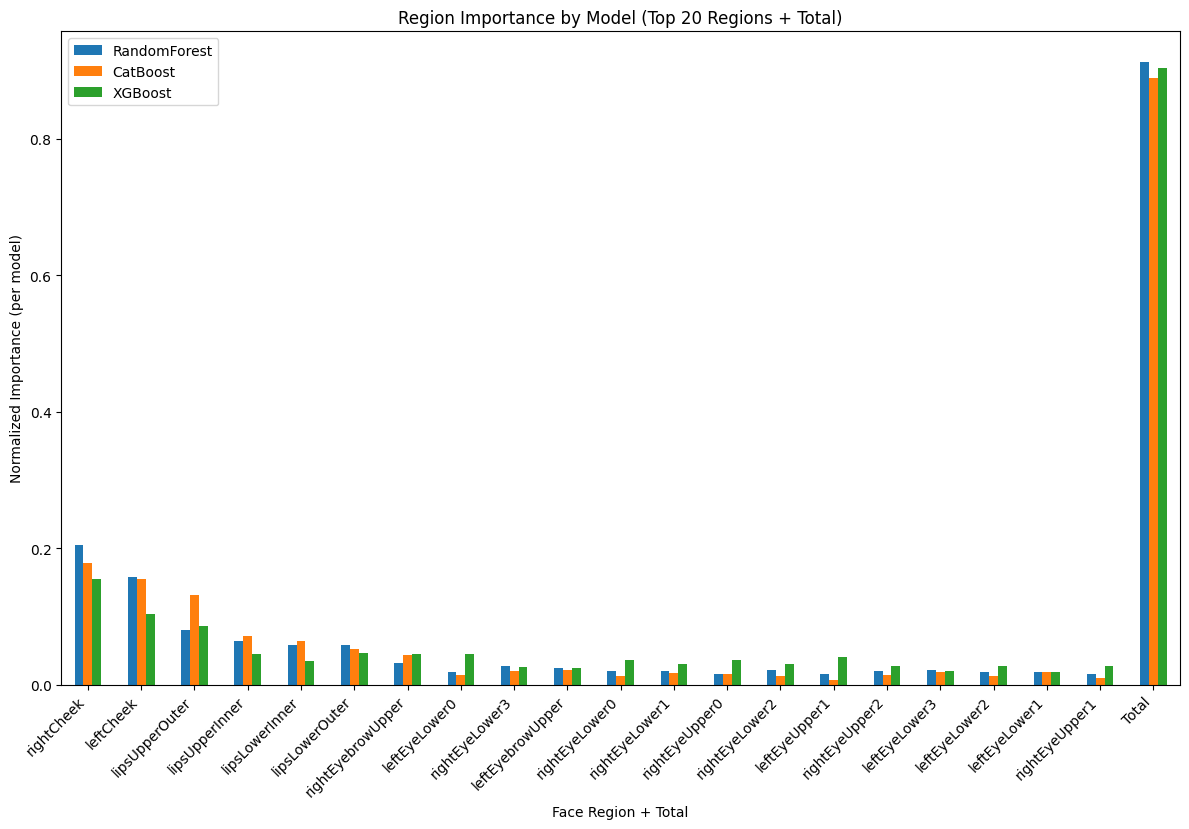

In [5]:
# Add a "Total" column (sum across regions per model, already normalized so will be 1.0 per model)
imp_top_with_total = imp_top.copy()
imp_top_with_total["Total"] = imp_top.sum(axis=1)

# Plot with the extra bar
plt.figure(figsize=(12, max(5, 0.35*len(imp_top_with_total.columns))))
imp_top_with_total.T.plot(kind="bar", figsize=(12, max(5, 0.4*len(imp_top_with_total.columns))))
plt.ylabel("Normalized Importance (per model)")
plt.xlabel("Face Region + Total")
plt.title(f"Region Importance by Model (Top {top_n} Regions + Total)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


<Figure size 1200x700 with 0 Axes>

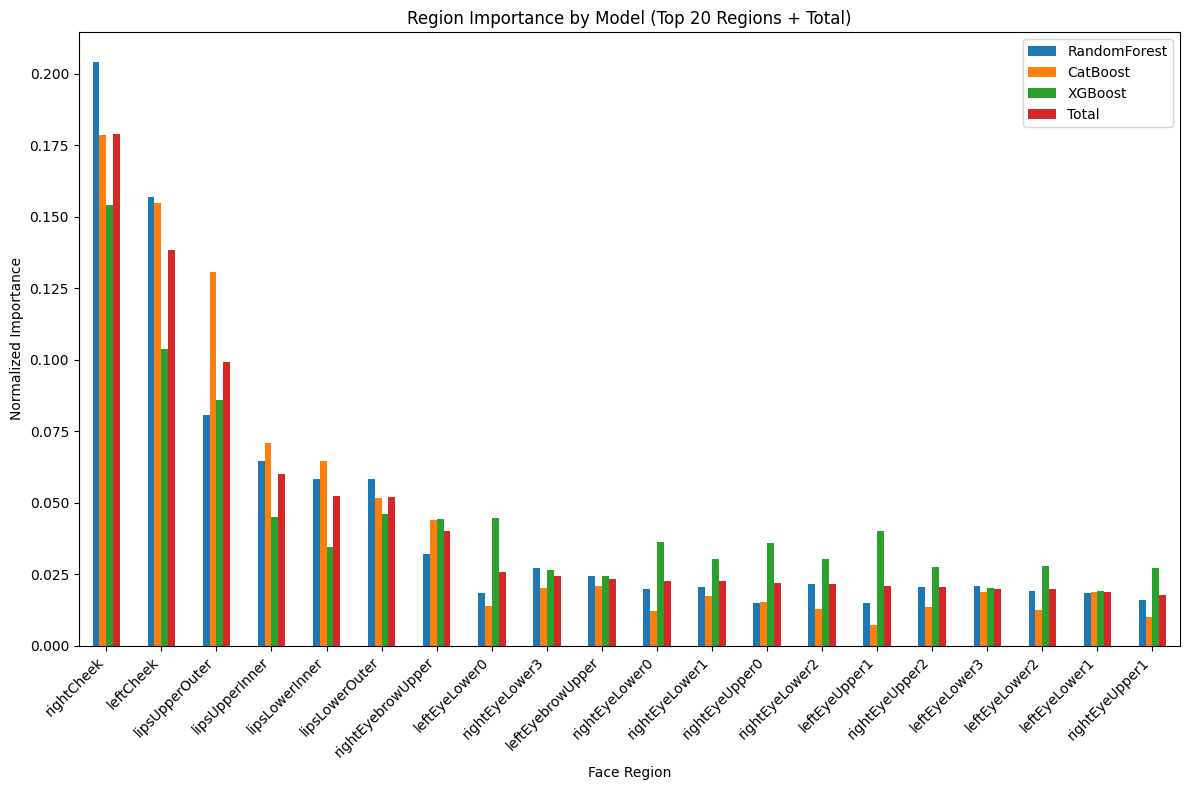

In [6]:
# imp_top = models x regions (normalized)
# Add "Total" row = mean across models (or sum if you prefer)
imp_top_with_total = imp_top.copy()
imp_top_with_total.loc["Total"] = imp_top.mean(axis=0)  # or .sum(axis=0)

# Now plot, including the Total as if it's another model
plt.figure(figsize=(12, max(5, 0.35*len(top_regions))))
imp_top_with_total.T.plot(kind="bar", figsize=(12, max(5, 0.4*len(top_regions))))
plt.ylabel("Normalized Importance")
plt.xlabel("Face Region")
plt.title(f"Region Importance by Model (Top {top_n} Regions + Total)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


<Figure size 1200x700 with 0 Axes>

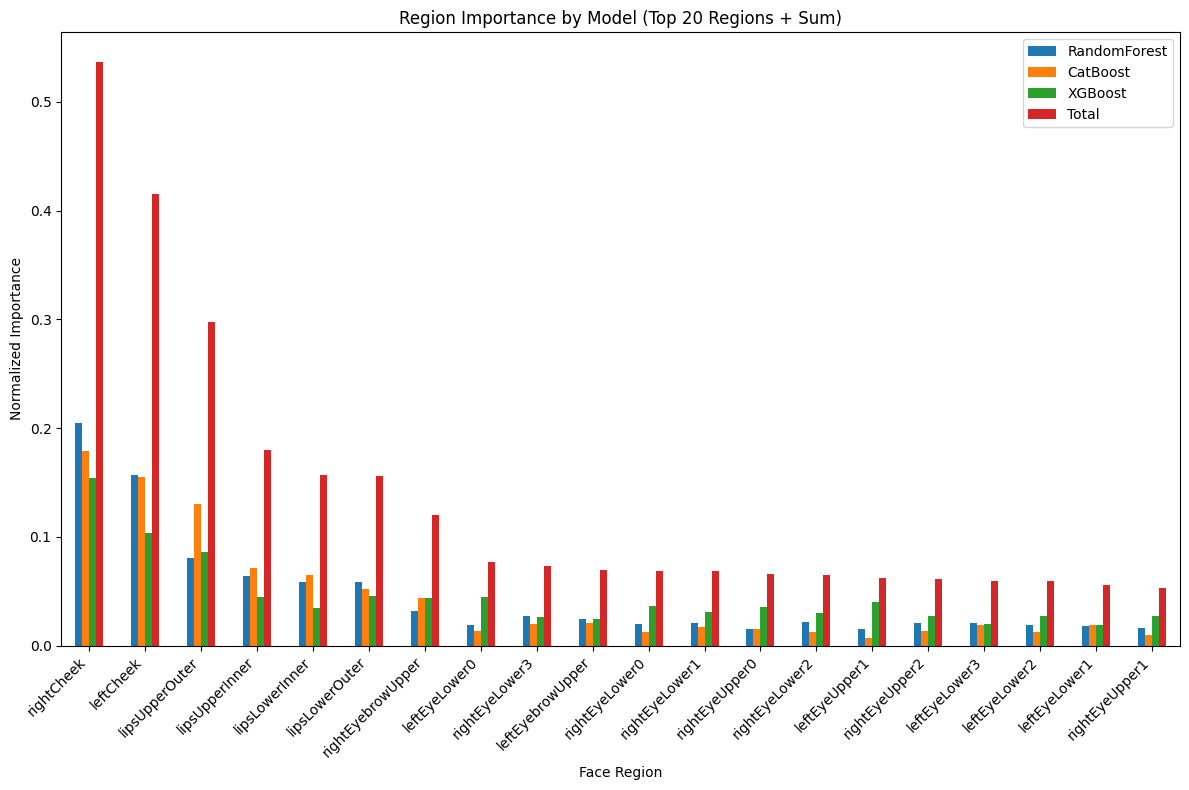

In [7]:
# imp_top = models x regions (normalized)
# Add "Total" row = sum across models
imp_top_with_total = imp_top.copy()
imp_top_with_total.loc["Total"] = imp_top.sum(axis=0)

# Now plot
plt.figure(figsize=(12, max(5, 0.35*len(top_regions))))
imp_top_with_total.T.plot(kind="bar", figsize=(12, max(5, 0.4*len(top_regions))))
plt.ylabel("Normalized Importance")
plt.xlabel("Face Region")
plt.title(f"Region Importance by Model (Top {top_n} Regions + Sum)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


AttributeError: module 'matplotlib.pyplot' has no attribute 'tit'

<Figure size 1200x700 with 0 Axes>

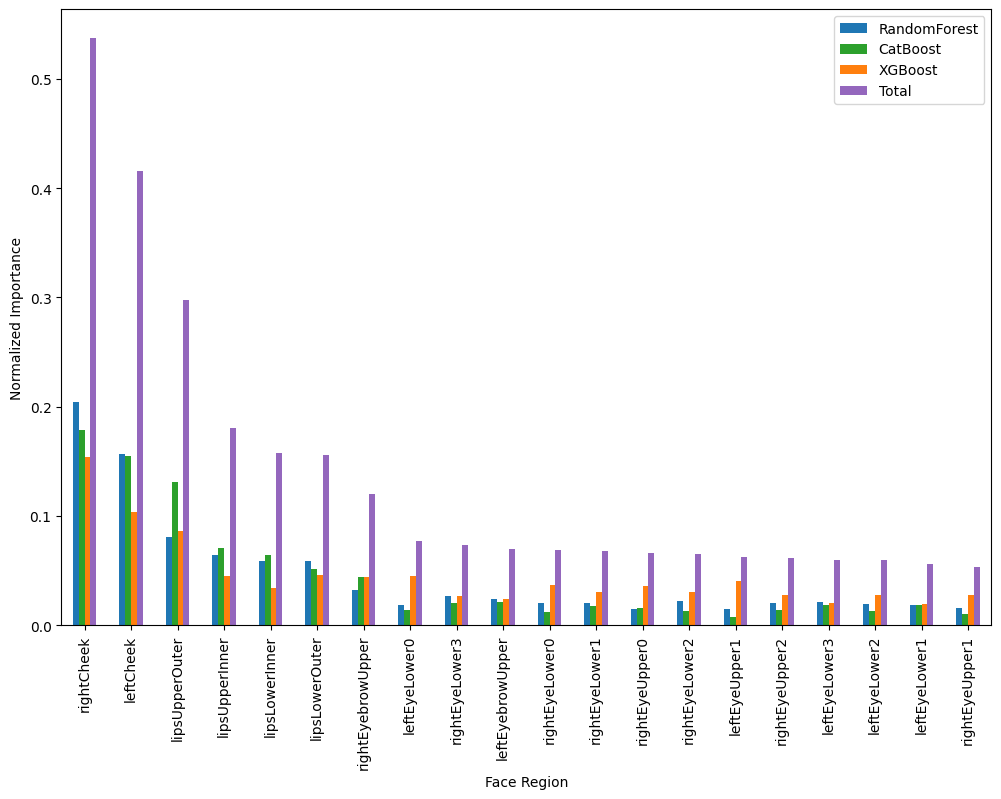

In [8]:
import matplotlib.pyplot as plt

# Define custom colors (avoid red)
custom_colors = ["#1f77b4",  # blue
                 "#2ca02c",  # green
                 "#ff7f0e",  # orange
                 "#9467bd"]  # purple

# Plot with sum included
plt.figure(figsize=(12, max(5, 0.35*len(top_regions))))
ax = imp_top_with_total.T.plot(
    kind="bar",
    figsize=(12, max(5, 0.4*len(top_regions))),
    color=custom_colors
)

plt.ylabel("Normalized Importance")
plt.xlabel("Face Region")
plt.tit# Add "Total" row = sum across models
imp_top_with_total = imp_top.copy()
imp_top_with_total.loc["Total"] = imp_top.sum(axis=0)

# Sort regions (columns) based on the Total row, descending
sorted_cols = imp_top_with_total.loc["Total"].sort_values(ascending=False).index
imp_top_sorted = imp_top_with_total[sorted_cols]

# Define custom colors (no red)
custom_colors = ["#1f77b4",  # blue (RandomForest)
                 "#2ca02c",  # green (CatBoost)
                 "#ff7f0e",  # orange (XGBoost)
                 "#9467bd"]  # purple (Total)

# Plot
plt.figure(figsize=(12, max(5, 0.35*len(sorted_cols))))
imp_top_sorted.T.plot(
    kind="bar",
    figsize=(12, max(5, 0.4*len(sorted_cols))),
    color=custom_colors
)

plt.ylabel("Importance")
plt.xlabel("Face Region")
plt.title(f"Region Importance by Model (Sorted by Sum)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
le(f"Region Importance by Model (Top {top_n} Regions + Sum)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


<Figure size 1200x700 with 0 Axes>

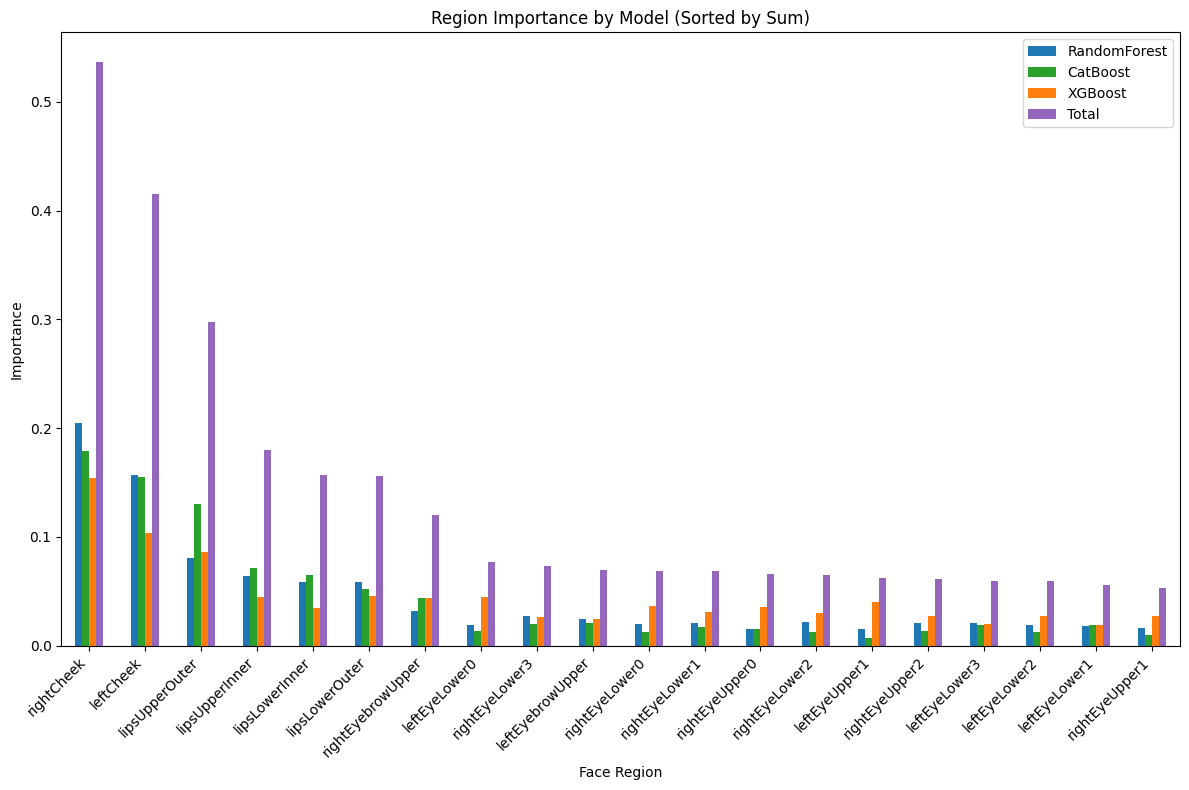

In [9]:
# Add "Total" row = sum across models
imp_top_with_total = imp_top.copy()
imp_top_with_total.loc["Total"] = imp_top.sum(axis=0)

# Sort regions (columns) based on the Total row, descending
sorted_cols = imp_top_with_total.loc["Total"].sort_values(ascending=False).index
imp_top_sorted = imp_top_with_total[sorted_cols]

# Define custom colors (no red)
custom_colors = ["#1f77b4",  # blue (RandomForest)
                 "#2ca02c",  # green (CatBoost)
                 "#ff7f0e",  # orange (XGBoost)
                 "#9467bd"]  # purple (Total)

# Plot
plt.figure(figsize=(12, max(5, 0.35*len(sorted_cols))))
imp_top_sorted.T.plot(
    kind="bar",
    figsize=(12, max(5, 0.4*len(sorted_cols))),
    color=custom_colors
)

plt.ylabel("Importance")
plt.xlabel("Face Region")
plt.title(f"Region Importance by Model (Sorted by Sum)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


<Figure size 1400x1120 with 0 Axes>

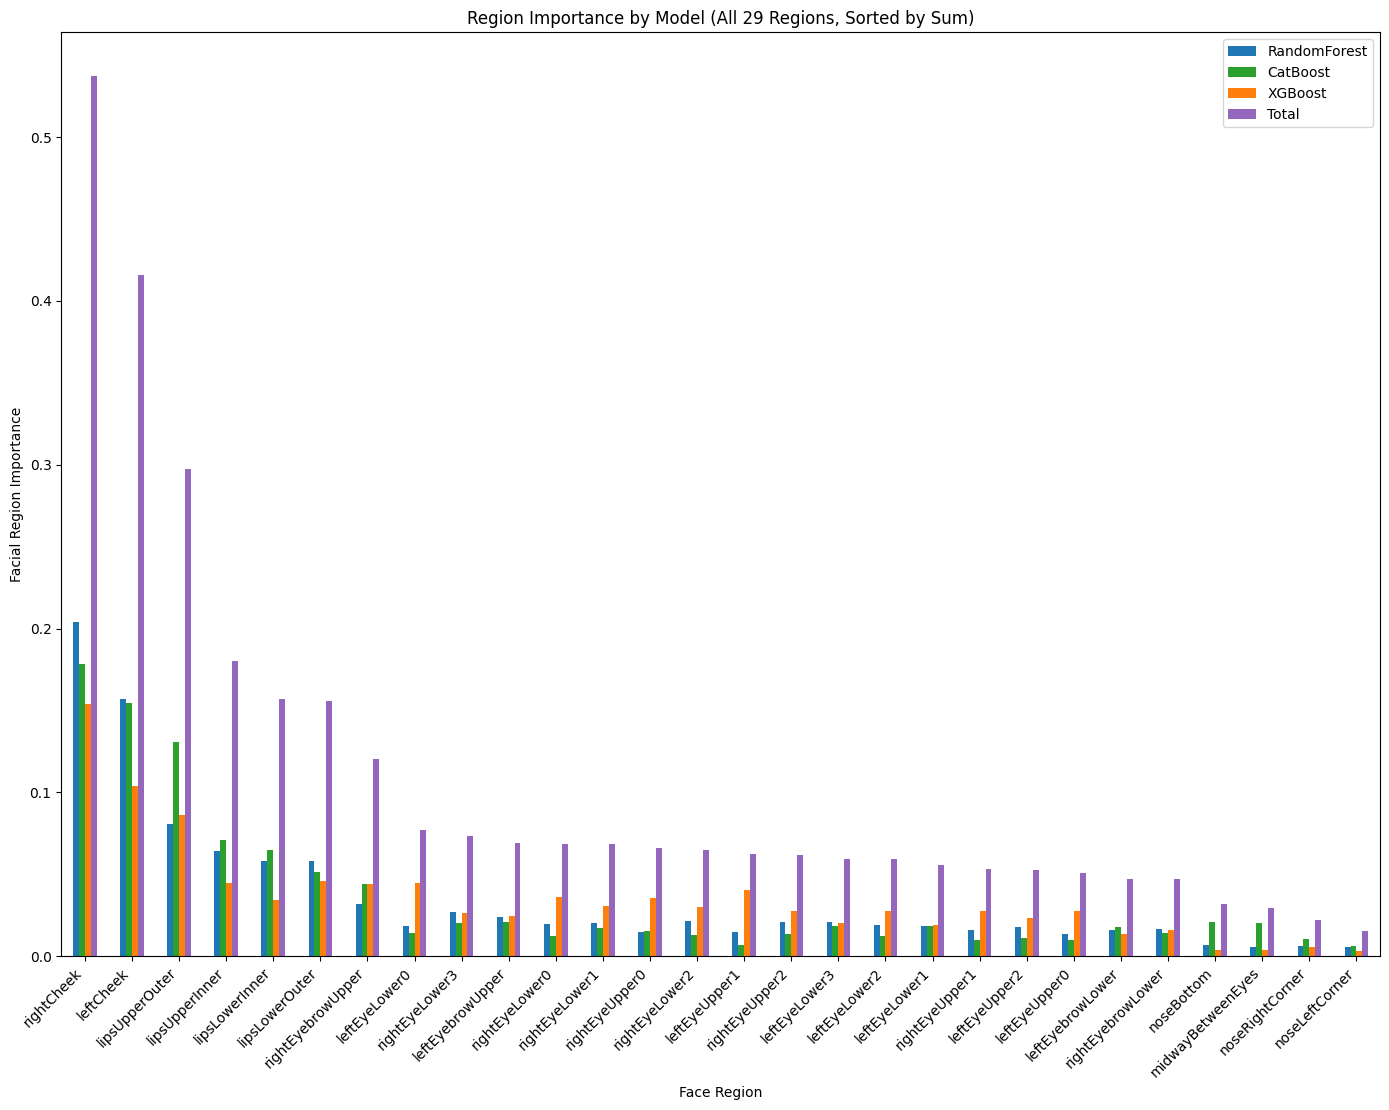

In [12]:
# Use all regions (no top_n cut)
imp_all = imp_norm.copy()  # this already has all 29 regions

# Add "Total" row = sum across models
imp_all_with_total = imp_all.copy()
imp_all_with_total.loc["Total"] = imp_all.sum(axis=0)

# Sort regions by Total descending
sorted_cols = imp_all_with_total.loc["Total"].sort_values(ascending=False).index
imp_all_sorted = imp_all_with_total[sorted_cols]

# Custom colors (no red)
custom_colors = ["#1f77b4",  # RandomForest
                 "#2ca02c",  # CatBoost
                 "#ff7f0e",  # XGBoost
                 "#9467bd"]  # Total

# Plot all 29 regions
plt.figure(figsize=(14, max(6, 0.4 * len(sorted_cols))))
imp_all_sorted.T.plot(
    kind="bar",
    figsize=(14, max(6, 0.4 * len(sorted_cols))),
    color=custom_colors
)

plt.ylabel("Facial Region Importance")
plt.xlabel("Face Region")
plt.title("Region Importance by Model (All 29 Regions, Sorted by Sum)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [13]:
# Save high-res
plt.tight_layout()
plt.savefig("facial_feature_importance_28_regions.png", dpi=400)  # PNG high-res
plt.savefig("facial_feature_importance_28_regions.pdf")           # vector version
plt.show()

<Figure size 640x480 with 0 Axes>

<Figure size 1400x1120 with 0 Axes>

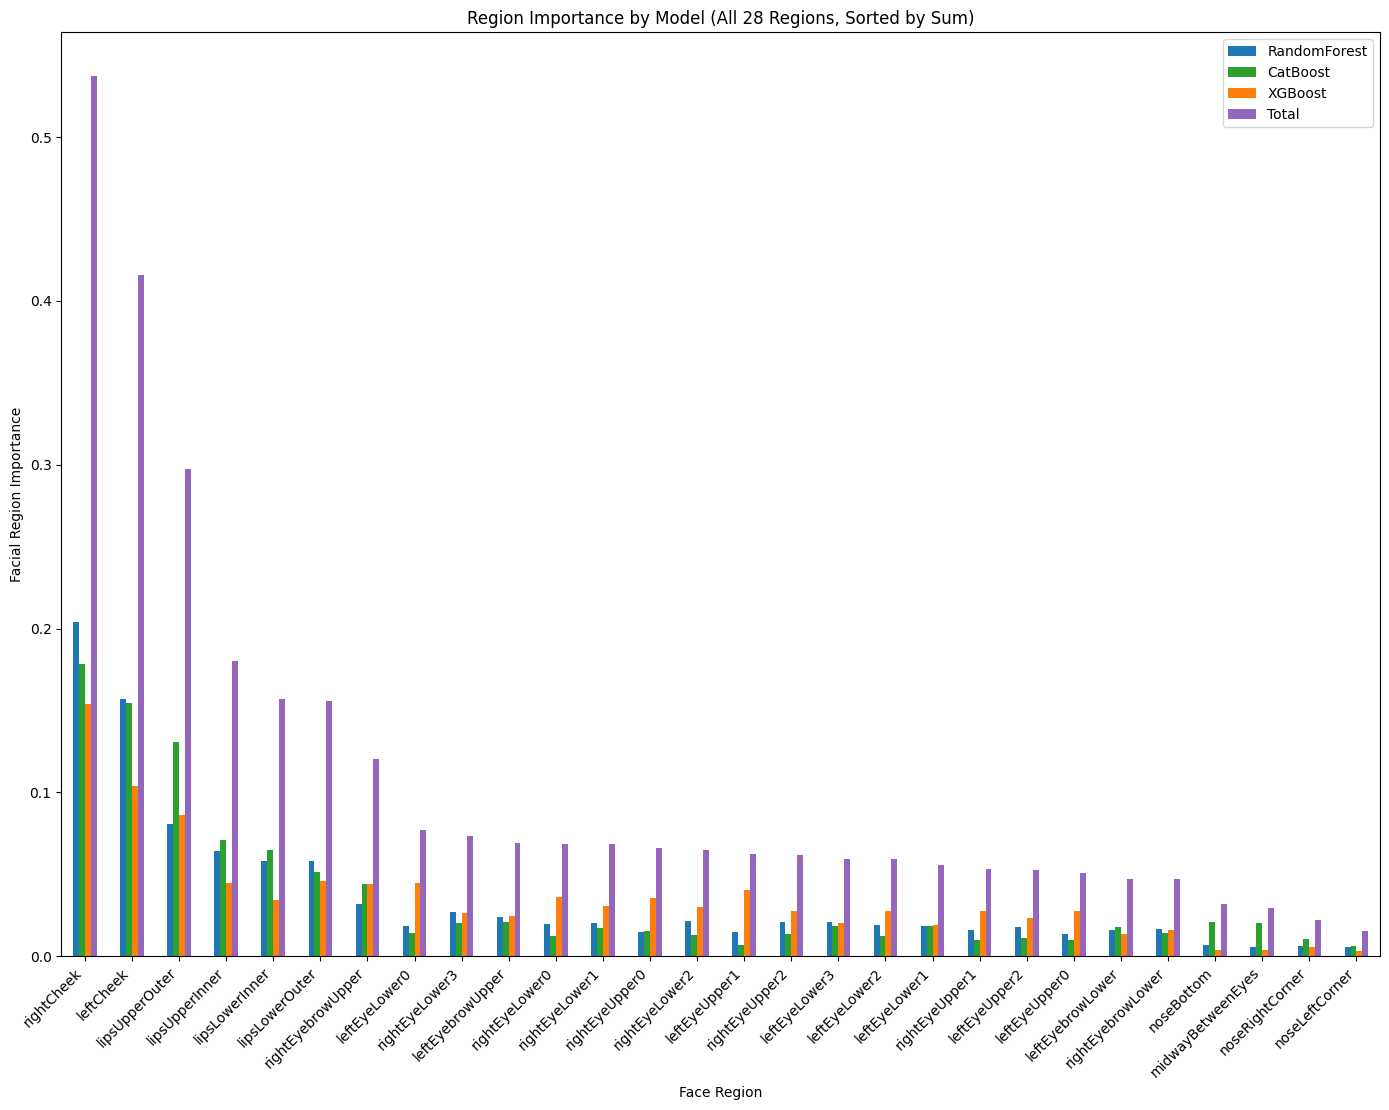

In [14]:
# Plot all 29 regions
plt.figure(figsize=(14, max(6, 0.4 * len(sorted_cols))))
ax = imp_all_sorted.T.plot(
    kind="bar",
    figsize=(14, max(6, 0.4 * len(sorted_cols))),
    color=custom_colors
)

plt.ylabel("Facial Region Importance")
plt.xlabel("Face Region")
plt.title("Region Importance by Model (All 28 Regions, Sorted by Sum)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Save high-resolution image
plt.savefig("region_importance_all_28.png", dpi=400, bbox_inches="tight")  # PNG (400 dpi)
plt.savefig("region_importance_all_28.pdf", bbox_inches="tight")          # PDF (vector)

plt.show()
